In [3]:
!pip install qiskit qiskit-aer qiskit-machine-learning qiskit-algorithms yfinance xgboost seaborn pylatexenc

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from qiskit.visualization import circuit_drawer
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes, PauliFeatureMap
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA, OptimizerResult

In [ ]:
%matplotlib inline

In [6]:
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2024-01-01")

data["Return"] = data["Close"].pct_change()
data["MA5"] = data["Close"].rolling(5).mean()
data["MA10"] = data["Close"].rolling(10).mean()
data["Volatility"] = data["Return"].rolling(5).std()
data["Target"] = (data["Return"].shift(-1) > 0).astype(int)

data = data.dropna()

/tmp/ipython-input-32808/3316706990.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


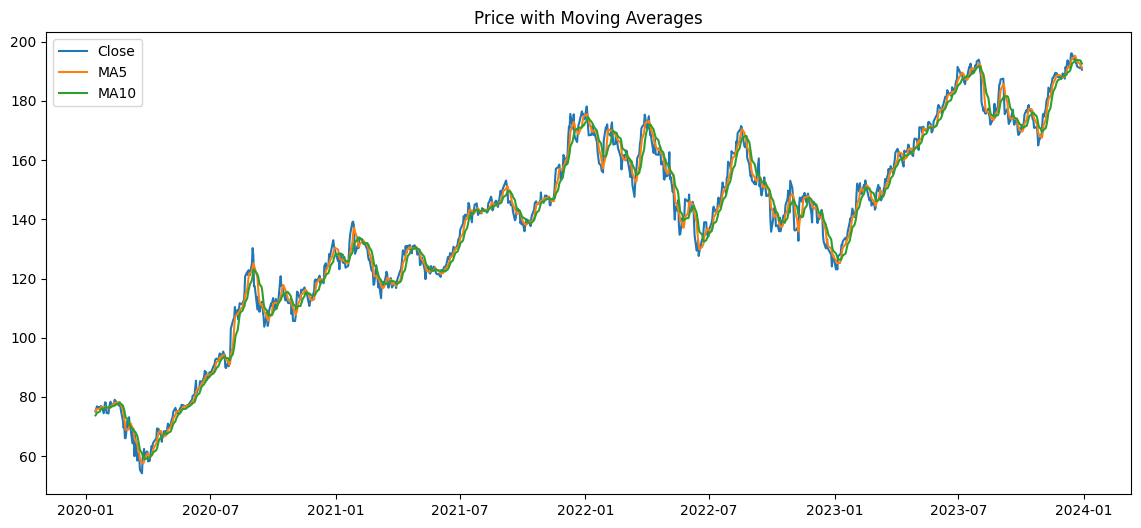

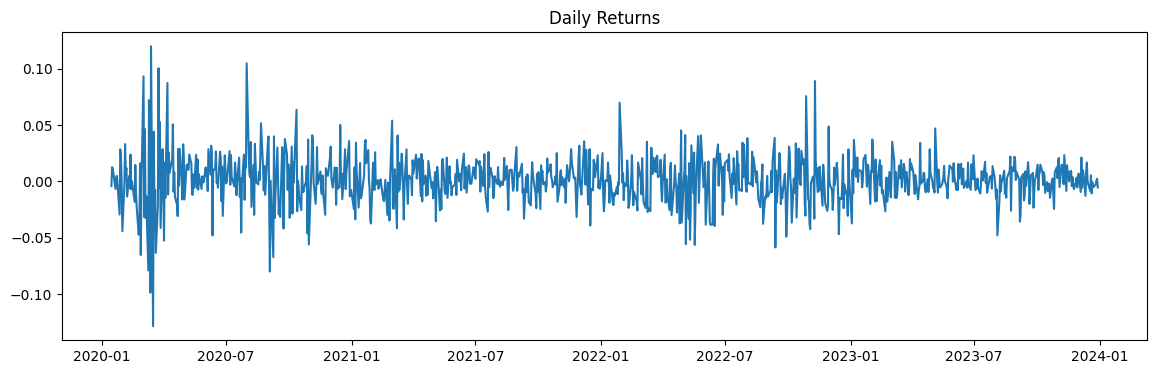

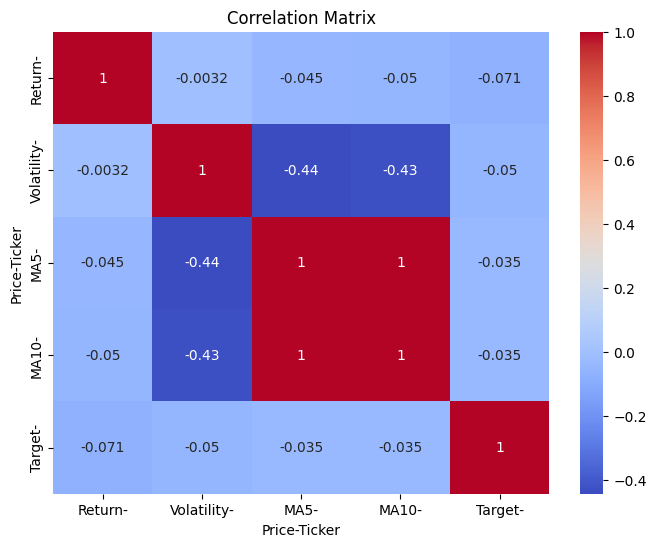

In [7]:
plt.figure(figsize=(14,6))
plt.plot(data.index, data["Close"], label="Close")
plt.plot(data.index, data["MA5"], label="MA5")
plt.plot(data.index, data["MA10"], label="MA10")
plt.title("Price with Moving Averages")
plt.legend()
plt.show()

print()

plt.figure(figsize=(14,4))
plt.plot(data.index, data["Return"])
plt.title("Daily Returns")
plt.show()

print()

plt.figure(figsize=(8,6))
sns.heatmap(data[["Return","Volatility","MA5","MA10","Target"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [8]:
features = ["Return","Volatility","MA5","MA10"]
X = data[features].values
y = data["Target"].values

split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

LogReg
Train: 0.5458
Test: 0.43
ROC: 0.4843

RandomForest
Train: 0.7616
Test: 0.52
ROC: 0.5655

XGBoost
Train: 0.9987
Test: 0.515
ROC: 0.5907



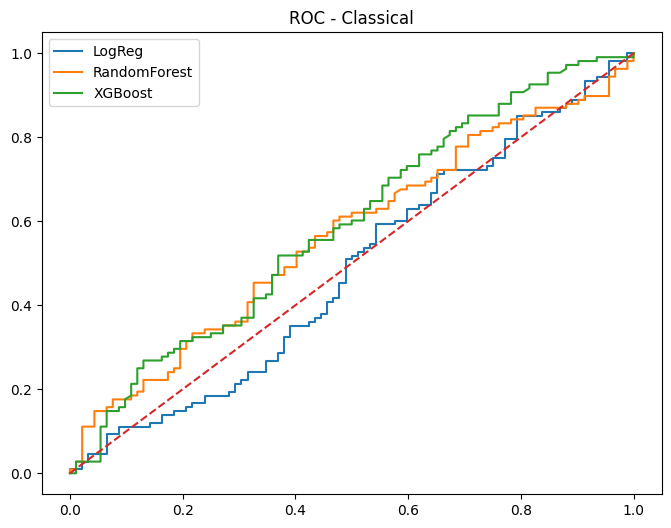

In [9]:
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=6),
    "XGBoost": XGBClassifier()
}

results = []

plt.figure(figsize=(8,6))

for name, model in models.items():

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    probs = model.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_test, probs)

    results.append([name, train_acc, test_acc, roc, "Classical", "-"])

    print(name)
    print("Train:", round(train_acc,4))
    print("Test:", round(test_acc,4))
    print("ROC:", round(roc,4))
    print()

    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')
plt.title("ROC - Classical")
plt.legend()
plt.show()

In [10]:
class CallbackOptimizer(COBYLA):
    def __init__(self, maxiter=100):
        super().__init__(maxiter=maxiter)
        self.history = []

    def minimize(self, fun, x0, jac=None, bounds=None):
        self.history = []

        def wrapped_fun(x):
            value = fun(x)
            self.history.append(value)
            print(f"Loss: {value:.4f}")
            return value

        result = super().minimize(wrapped_fun, x0, jac, bounds)
        result.history = self.history
        return result

def train_vqc(feature_map, ansatz, label, maxiter=100):

    optimizer = CallbackOptimizer(maxiter=maxiter)

    vqc = VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer
    )

    start = time.time()
    vqc.fit(X_train, y_train)
    train_time = time.time() - start

    train_acc = accuracy_score(y_train, vqc.predict(X_train))
    test_acc = accuracy_score(y_test, vqc.predict(X_test))
    probs = vqc.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_test, probs)

    print(f"{label} ROC: {roc:.4f} | Time: {train_time:.1f}s")

    return vqc, optimizer.history, train_acc, test_acc, roc, train_time

In [11]:
configs = {
    "ZZ_r1_RA_r2": (ZZFeatureMap(4, reps=1), RealAmplitudes(4, reps=2)),
    "ZZ_r2_RA_r2": (ZZFeatureMap(4, reps=2), RealAmplitudes(4, reps=2)),
    "ZZ_r2_RA_r3": (ZZFeatureMap(4, reps=2), RealAmplitudes(4, reps=3)),
    "Pauli_r1_RA_r2": (PauliFeatureMap(4, reps=1), RealAmplitudes(4, reps=2))
}

/tmp/ipython-input-32808/271364915.py:2: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  "ZZ_r1_RA_r2": (ZZFeatureMap(4, reps=1), RealAmplitudes(4, reps=2)),
/tmp/ipython-input-32808/271364915.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  "ZZ_r1_RA_r2": (ZZFeatureMap(4, reps=1), RealAmplitudes(4, reps=2)),
/tmp/ipython-input-32808/271364915.py:3: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map functio

In [12]:
vqc_models = {}
loss_histories = {}
roc_scores = {}
train_times = {}

for name, (fmap, ansatz) in configs.items():

    print("\nTraining:", name)

    model, losses, train_acc, test_acc, roc, train_time = train_vqc(fmap, ansatz, name)

    vqc_models[name] = model
    loss_histories[name] = losses
    roc_scores[name] = roc
    train_times[name] = train_time

    results.append([name, train_acc, test_acc, roc, "Quantum", ansatz.num_parameters])


Training: ZZ_r1_RA_r2
Loss: 1.0186
Loss: 1.0445
Loss: 1.0146
Loss: 1.0225
Loss: 1.0104
Loss: 1.0241
Loss: 1.0131
Loss: 1.0222
Loss: 1.0095
Loss: 1.0265
Loss: 1.0095
Loss: 1.0095
Loss: 1.0095
Loss: 1.0292
Loss: 1.0341
Loss: 1.0096
Loss: 1.0113
Loss: 1.0094
Loss: 1.0130
Loss: 1.0086
Loss: 1.0074
Loss: 1.0061
Loss: 1.0035
Loss: 1.0009
Loss: 0.9993
Loss: 0.9987
Loss: 0.9993
Loss: 0.9990
Loss: 0.9989
Loss: 0.9987
Loss: 0.9979
Loss: 0.9967
Loss: 0.9960
Loss: 0.9957
Loss: 0.9946
Loss: 0.9941
Loss: 0.9937
Loss: 0.9935
Loss: 0.9936
Loss: 0.9936
Loss: 0.9940
Loss: 0.9935
Loss: 0.9932
Loss: 0.9937
Loss: 0.9939
Loss: 0.9928
Loss: 0.9922
Loss: 0.9919
Loss: 0.9919
Loss: 0.9918
Loss: 0.9923
Loss: 0.9917
Loss: 0.9918
Loss: 0.9915
Loss: 0.9913
Loss: 0.9914
Loss: 0.9913
Loss: 0.9913
Loss: 0.9920
Loss: 0.9904
Loss: 0.9905
Loss: 0.9901
Loss: 0.9899
Loss: 0.9899
Loss: 0.9901
Loss: 0.9891
Loss: 0.9890
Loss: 0.9891
Loss: 0.9889
Loss: 0.9885
Loss: 0.9881
Loss: 0.9880
Loss: 0.9878
Loss: 0.9882
Loss: 0.9880
Lo

ZZ_r1_RA_r2 ROC: 0.4096 | Time: 336.5s

Training: ZZ_r2_RA_r2
Loss: 1.0475
Loss: 1.0585
Loss: 1.0491
Loss: 1.0417
Loss: 1.0454
Loss: 1.0113
Loss: 1.0220
Loss: 1.0298
Loss: 1.0270
Loss: 1.0285
Loss: 1.0113
Loss: 1.0113
Loss: 1.0113
Loss: 1.0232
Loss: 1.0146
Loss: 1.0126
Loss: 1.0140
Loss: 1.0113
Loss: 1.0113
Loss: 1.0104
Loss: 1.0104
Loss: 1.0104
Loss: 1.0083
Loss: 1.0077
Loss: 1.0055
Loss: 1.0037
Loss: 1.0022
Loss: 1.0014
Loss: 1.0004
Loss: 0.9998
Loss: 0.9991
Loss: 0.9987
Loss: 0.9983
Loss: 0.9986
Loss: 0.9983
Loss: 0.9987
Loss: 0.9986
Loss: 0.9982
Loss: 0.9981
Loss: 0.9970
Loss: 0.9962
Loss: 0.9965
Loss: 0.9964
Loss: 0.9954
Loss: 0.9949
Loss: 0.9952
Loss: 0.9947
Loss: 0.9942
Loss: 0.9937
Loss: 0.9933
Loss: 0.9930
Loss: 0.9932
Loss: 0.9935
Loss: 0.9925
Loss: 0.9923
Loss: 0.9921
Loss: 0.9921
Loss: 0.9921
Loss: 0.9914
Loss: 0.9910
Loss: 0.9910
Loss: 0.9914
Loss: 0.9905
Loss: 0.9904
Loss: 0.9901
Loss: 0.9898
Loss: 0.9897
Loss: 0.9898
Loss: 0.9902
Loss: 0.9894
Loss: 0.9889
Loss: 0.9889
Lo

ZZ_r2_RA_r2 ROC: 0.4158 | Time: 397.9s

Training: ZZ_r2_RA_r3
Loss: 1.0442
Loss: 1.0606
Loss: 1.0397
Loss: 1.0322
Loss: 1.0587
Loss: 1.0415
Loss: 1.0323
Loss: 1.0310
Loss: 1.0307
Loss: 1.0435
Loss: 1.0321
Loss: 1.0316
Loss: 1.0316
Loss: 1.0280
Loss: 1.0280
Loss: 1.0280
Loss: 1.0280
Loss: 1.0173
Loss: 1.0396
Loss: 1.0238
Loss: 1.0226
Loss: 1.0251
Loss: 1.0278
Loss: 1.0240
Loss: 1.0198
Loss: 1.0105
Loss: 1.0322
Loss: 1.0062
Loss: 0.9983
Loss: 1.0161
Loss: 1.0043
Loss: 1.0068
Loss: 0.9983
Loss: 1.0187
Loss: 0.9976
Loss: 1.0055
Loss: 1.0011
Loss: 1.0114
Loss: 0.9976
Loss: 1.0208
Loss: 0.9976
Loss: 1.0183
Loss: 0.9976
Loss: 1.0209
Loss: 1.0073
Loss: 0.9990
Loss: 0.9992
Loss: 0.9989
Loss: 0.9984
Loss: 0.9979
Loss: 0.9962
Loss: 0.9964
Loss: 0.9973
Loss: 0.9941
Loss: 0.9932
Loss: 0.9917
Loss: 0.9913
Loss: 0.9903
Loss: 0.9902
Loss: 0.9893
Loss: 0.9900
Loss: 0.9900
Loss: 0.9886
Loss: 0.9888
Loss: 0.9888
Loss: 0.9888
Loss: 0.9895
Loss: 0.9866
Loss: 0.9855
Loss: 0.9844
Loss: 0.9846
Loss: 0.9845
Lo

ZZ_r2_RA_r3 ROC: 0.4544 | Time: 423.5s

Training: Pauli_r1_RA_r2
Loss: 1.0349
Loss: 1.0647
Loss: 1.0345
Loss: 1.0350
Loss: 1.0306
Loss: 1.0528
Loss: 1.0309
Loss: 1.0472
Loss: 1.0210
Loss: 1.0341
Loss: 1.0210
Loss: 1.0210
Loss: 1.0210
Loss: 1.0186
Loss: 1.0469
Loss: 1.0158
Loss: 1.0057
Loss: 1.0207
Loss: 1.0116
Loss: 1.0222
Loss: 1.0074
Loss: 1.0156
Loss: 1.0089
Loss: 1.0217
Loss: 1.0062
Loss: 1.0035
Loss: 1.0079
Loss: 1.0034
Loss: 1.0039
Loss: 1.0030
Loss: 1.0028
Loss: 1.0038
Loss: 1.0025
Loss: 1.0026
Loss: 1.0024
Loss: 1.0000
Loss: 0.9991
Loss: 0.9977
Loss: 0.9974
Loss: 0.9969
Loss: 0.9967
Loss: 0.9967
Loss: 0.9967
Loss: 0.9961
Loss: 0.9960
Loss: 0.9963
Loss: 0.9960
Loss: 0.9953
Loss: 0.9959
Loss: 0.9953
Loss: 0.9947
Loss: 0.9946
Loss: 0.9948
Loss: 0.9947
Loss: 0.9947
Loss: 0.9944
Loss: 0.9940
Loss: 0.9946
Loss: 0.9937
Loss: 0.9936
Loss: 0.9938
Loss: 0.9935
Loss: 0.9930
Loss: 0.9932
Loss: 0.9931
Loss: 0.9923
Loss: 0.9920
Loss: 0.9914
Loss: 0.9913
Loss: 0.9909
Loss: 0.9905
Loss: 0.9902

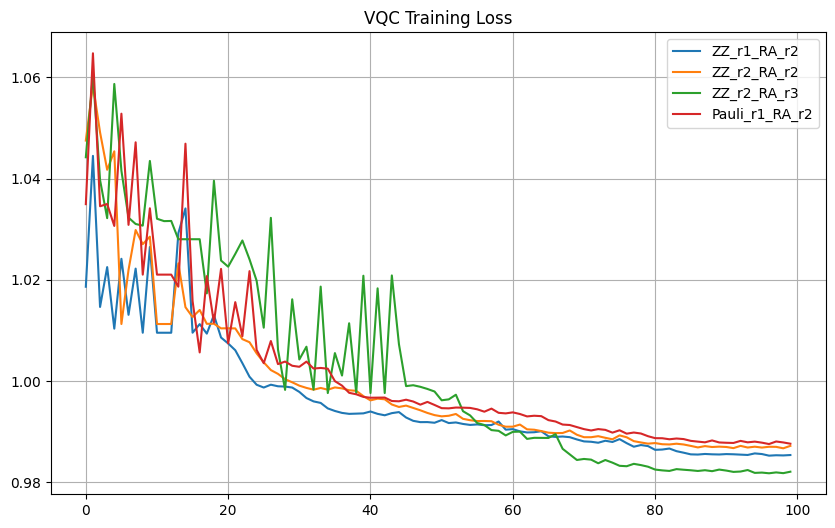

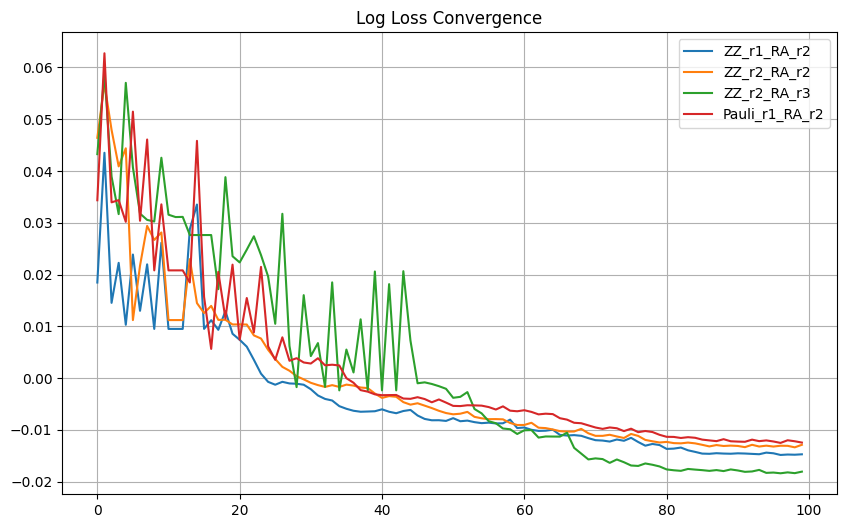

In [13]:
plt.figure(figsize=(10,6))
for name, losses in loss_histories.items():
    plt.plot(losses, label=name)
plt.title("VQC Training Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
for name, losses in loss_histories.items():
    plt.plot(np.log(losses), label=name)
plt.title("Log Loss Convergence")
plt.legend()
plt.grid(True)
plt.show()

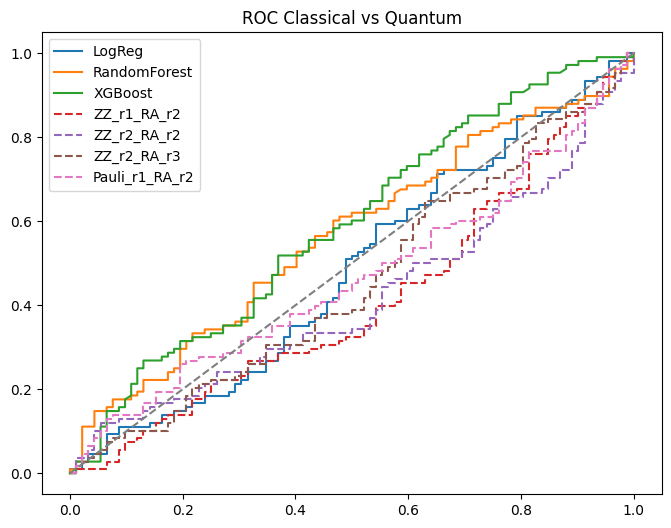

In [14]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

for name, model in vqc_models.items():
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, linestyle="--", label=name)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Classical vs Quantum")
plt.show()

In [15]:
print("Stability check:\n")

for name, (fmap, ansatz) in configs.items():
    scores = []
    for seed in range(5):
        np.random.seed(seed)

        vqc_tmp = VQC(
            feature_map=fmap,
            ansatz=ansatz,
            optimizer=COBYLA(maxiter=50)
        )

        vqc_tmp.fit(X_train, y_train)

        probs = vqc_tmp.predict_proba(X_test)[:,1]
        scores.append(roc_auc_score(y_test, probs))

    print(name,
          "Mean:", round(np.mean(scores),4),
          "Std:", round(np.std(scores),4))

Stability check:



ZZ_r1_RA_r2 Mean: 0.4353 Std: 0.0288


ZZ_r2_RA_r2 Mean: 0.4931 Std: 0.0031


ZZ_r2_RA_r3 Mean: 0.4997 Std: 0.0385


Pauli_r1_RA_r2 Mean: 0.4443 Std: 0.036


In [21]:
meta_X_train = np.column_stack([
    models["RandomForest"].predict_proba(X_train)[:,1],
    vqc_models["ZZ_r2_RA_r3"].predict_proba(X_train)[:,1]
])

meta_X_test = np.column_stack([
    models["RandomForest"].predict_proba(X_test)[:,1],
    vqc_models["ZZ_r2_RA_r3"].predict_proba(X_test)[:,1]
])

meta_model = LogisticRegression()
meta_model.fit(meta_X_train, y_train)

meta_probs = meta_model.predict_proba(meta_X_test)[:,1]
meta_roc = roc_auc_score(y_test, meta_probs)

print("Stacking ROC:", round(meta_roc,4))

results.append(["Stacking_RF_VQC", "-", "-", meta_roc, "Hybrid", 2])

results_df = pd.DataFrame(results,
                          columns=["Model","Train Acc","Test Acc","ROC-AUC","Type","Parameters"])


Stacking ROC: 0.5536


In [25]:
results_df = results_df.drop_duplicates(subset=["Model"], keep="first").reset_index(drop=True)


print("Final Results:\n")
print(results_df)


Final Results:

             Model Train Acc Test Acc   ROC-AUC       Type Parameters
0           LogReg  0.545797     0.43  0.484300  Classical          -
1     RandomForest  0.761606     0.52  0.565469  Classical          -
2          XGBoost  0.998745    0.515  0.590680  Classical          -
3      ZZ_r1_RA_r2  0.560853     0.42  0.409622    Quantum         12
4      ZZ_r2_RA_r2  0.549561    0.415  0.415761    Quantum         12
5      ZZ_r2_RA_r3  0.549561     0.44  0.454408    Quantum         16
6   Pauli_r1_RA_r2  0.564617    0.475  0.464875    Quantum         12
7  Stacking_RF_VQC         -        -  0.553643     Hybrid          2


In [38]:
f1_scores = []

for name, model in models.items():
    preds = model.predict(X_test)
    f1_scores.append(f1_score(y_test, preds))

for name, model in vqc_models.items():
    preds = model.predict(X_test)
    f1_scores.append(f1_score(y_test, preds))

meta_preds = meta_model.predict(meta_X_test)
f1_scores.append(f1_score(y_test, meta_preds))

results_df["F1"] = f1_scores

print(results_df)

             Model Train Acc Test Acc   ROC-AUC       Type Parameters  \
0           LogReg  0.545797     0.43  0.484300  Classical          -   
1     RandomForest  0.761606     0.52  0.565469  Classical          -   
2          XGBoost  0.998745    0.515  0.590680  Classical          -   
3      ZZ_r1_RA_r2  0.560853     0.42  0.409622    Quantum         12   
4      ZZ_r2_RA_r2  0.549561    0.415  0.415761    Quantum         12   
5      ZZ_r2_RA_r3  0.549561     0.44  0.454408    Quantum         16   
6   Pauli_r1_RA_r2  0.564617    0.475  0.464875    Quantum         12   
7  Stacking_RF_VQC         -        -  0.553643     Hybrid          2   

         F1  
0  0.269231  
1  0.333333  
2  0.445714  
3  0.486726  
4  0.412060  
5  0.445545  
6  0.492754  
7  0.279412  


In [39]:
lin_model = LogisticRegression()
lin_model.fit(X_train, y_train)

train_sep = lin_model.score(X_train, y_train)
test_sep = lin_model.score(X_test, y_test)

print("Theoretical linear separability:")
print("Train separability:", round(train_sep,4))
print("Test separability:", round(test_sep,4))

Theoretical linear separability:
Train separability: 0.5458
Test separability: 0.43


<Figure size 640x480 with 0 Axes>

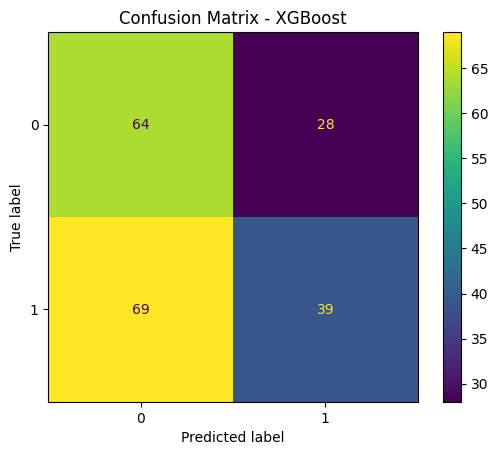

<Figure size 640x480 with 0 Axes>

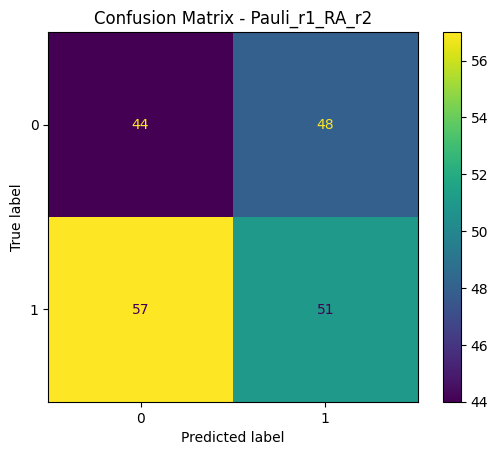

In [28]:
best_classical = max(models.items(),
                     key=lambda x: roc_auc_score(y_test, x[1].predict_proba(X_test)[:,1]))

best_quantum = max(vqc_models.items(),
                   key=lambda x: roc_auc_score(y_test, x[1].predict_proba(X_test)[:,1]))

plt.figure()
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_classical[1].predict(X_test)
)
plt.title(f"Confusion Matrix - {best_classical[0]}")
plt.show()

plt.figure()
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_quantum[1].predict(X_test)
)
plt.title(f"Confusion Matrix - {best_quantum[0]}")
plt.show()


Stacking model coefficients:
  RandomForest weight: 9.555
  VQC weight: 1.620
  Intercept: -5.739


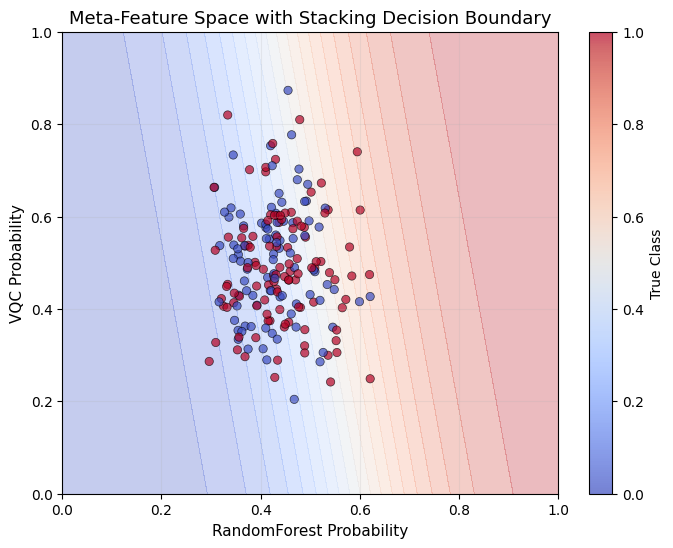

In [42]:
plt.figure(figsize=(8,6))

xx, yy = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = meta_model.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.3)

scatter = plt.scatter(meta_X_test[:,0], meta_X_test[:,1],
                      c=y_test, cmap="coolwarm",
                      edgecolors='black', linewidth=0.5, alpha=0.7)

plt.colorbar(scatter, label="True Class")
plt.xlabel("RandomForest Probability", fontsize=11)
plt.ylabel("VQC Probability", fontsize=11)
plt.title("Meta-Feature Space with Stacking Decision Boundary", fontsize=13)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.2)

print(f"\nStacking model coefficients:")
print(f"  RandomForest weight: {meta_model.coef_[0][0]:.3f}")
print(f"  VQC weight: {meta_model.coef_[0][1]:.3f}")
print(f"  Intercept: {meta_model.intercept_[0]:.3f}")
plt.show()

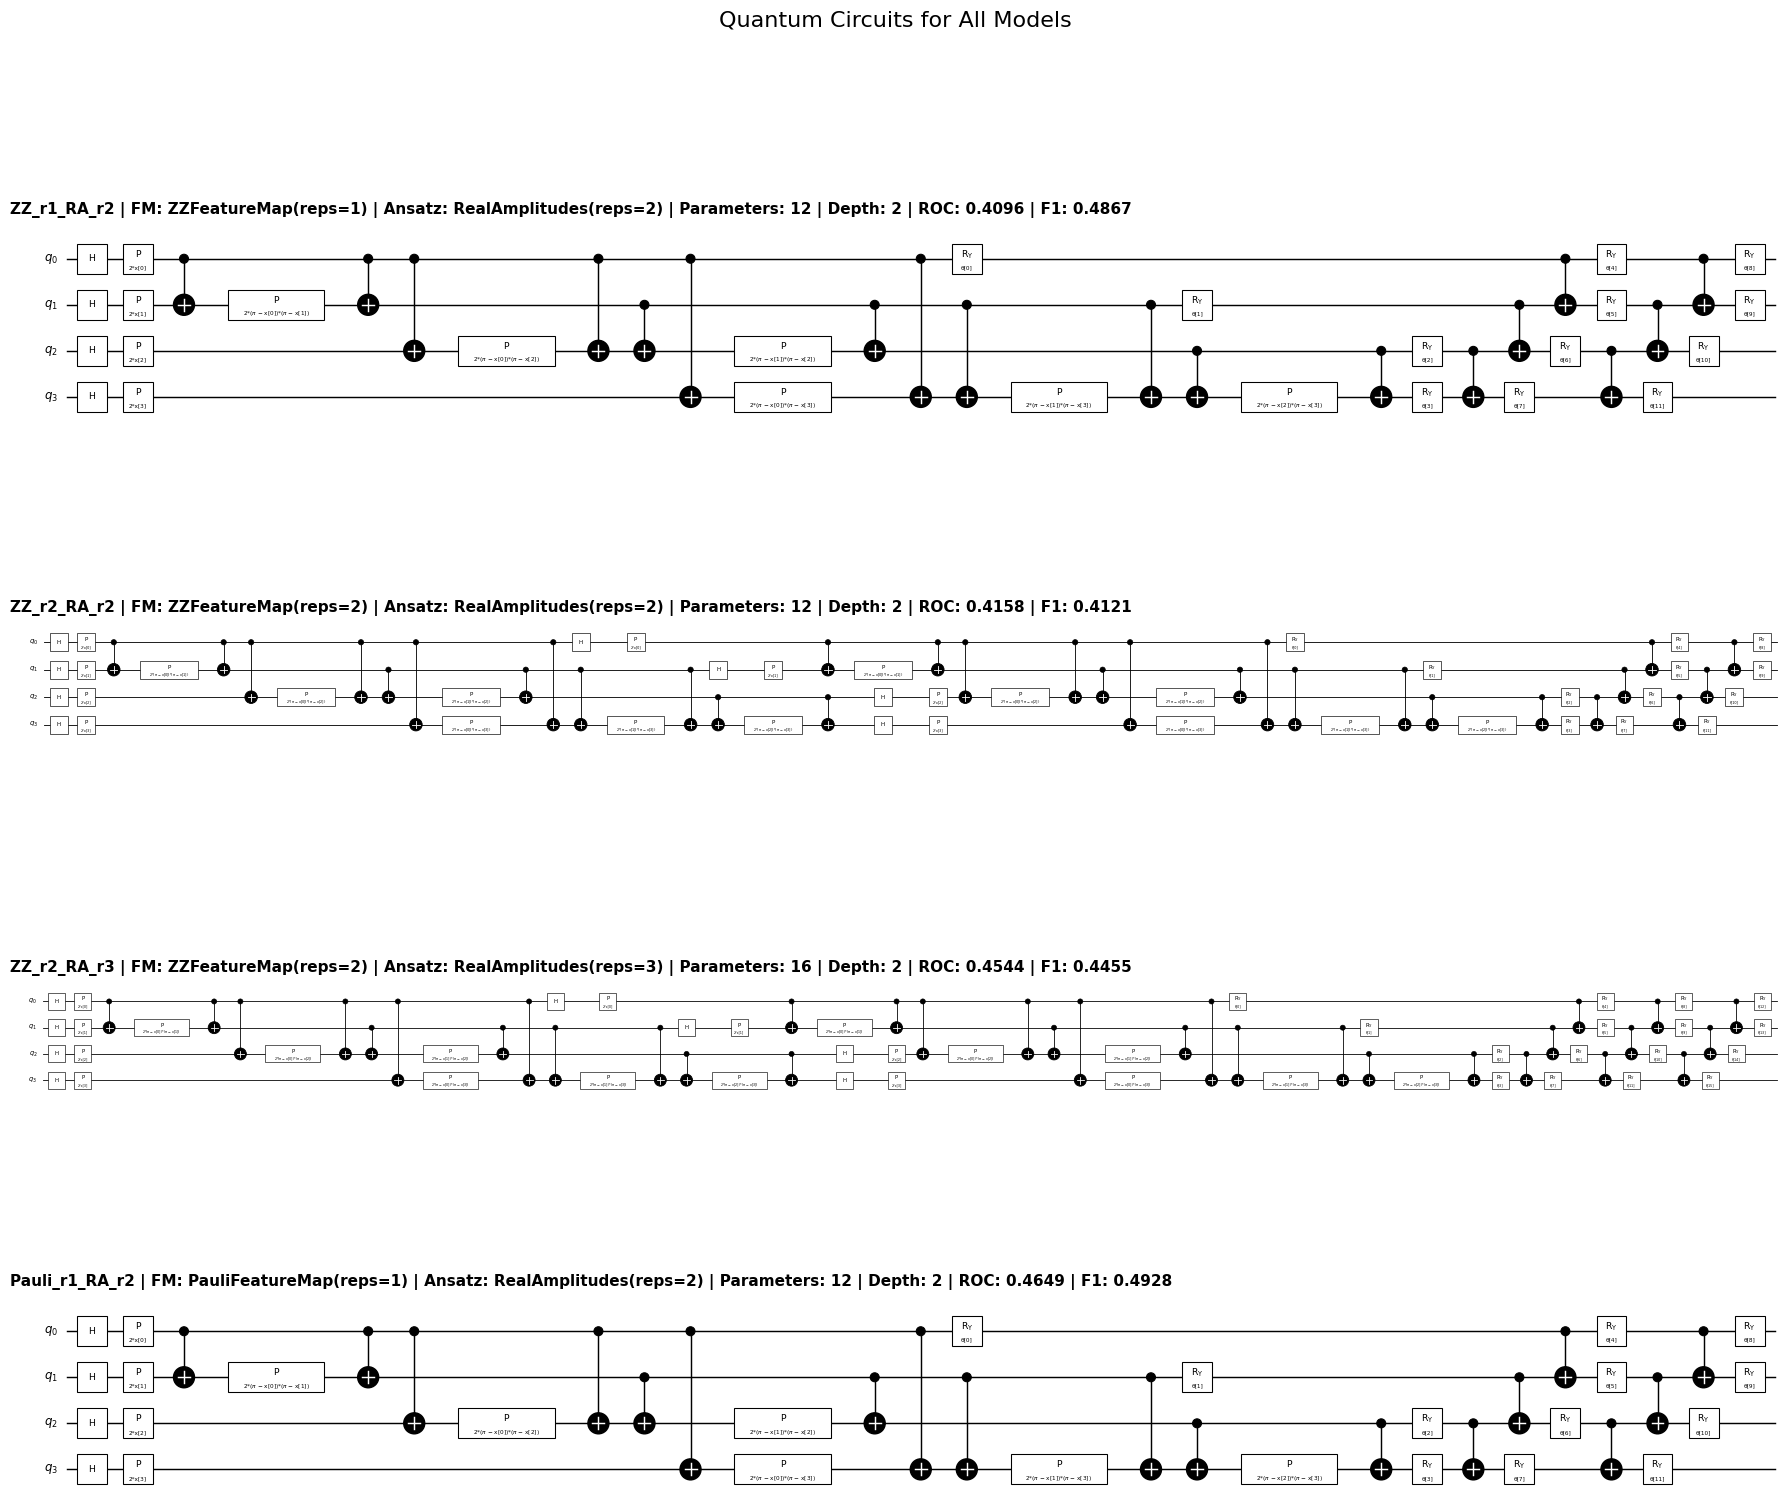

In [37]:
quantum_models = list(configs.items())

fig, axes = plt.subplots(len(quantum_models), 1, figsize=(18, 4*len(quantum_models)))

if len(quantum_models) == 1:
    axes = [axes]

for idx, (name, (fmap, ansatz)) in enumerate(quantum_models):
    full_circuit = fmap.compose(ansatz)

    ax = axes[idx]
    circuit_drawer(full_circuit.decompose(), output='mpl', style={'name': 'bw'},
                   scale=0.6, ax=ax, plot_barriers=False, fold=120)

    roc_val = roc_scores.get(name, 0)
    f1_val = results_df[results_df["Model"] == name]["F1"].values[0] if name in results_df["Model"].values else 0

    ax.set_title(f"{name} | FM: {type(fmap).__name__}(reps={fmap.reps}) | "
                 f"Ansatz: {type(ansatz).__name__}(reps={ansatz.reps}) | "
                 f"Parameters: {ansatz.num_parameters} | Depth: {full_circuit.depth()} | "
                 f"ROC: {roc_val:.4f} | F1: {f1_val:.4f}",
                 fontsize=11, fontweight='bold', loc='left')

plt.suptitle("Quantum Circuits for All Models", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()